In [1]:
%matplotlib inline


# Pass heat maps

Make a heat map of all teams passes during a tournament.
In order to add context, we set a window for danger
passes to be those in 15 seconds leading up to a shot.

..  youtube:: cgn4fvWo5l0
   :width: 640
   :height: 349


We will need these libraries



In [2]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch, Sbopen, VerticalPitch
import pandas as pd

## Opening the dataset

To get games by England Women's team we need to filter them in a dataframe - if they played as a home or away team.
We also calculate number of games to normalize the diagrams later on



In [3]:
#open the data
parser = Sbopen()
df_match = parser.match(competition_id=72, season_id=30)
#our team
team = "England Women's"
#get list of games by our team, either home or away
match_ids = df_match.loc[(df_match["home_team_name"] == team) | (df_match["away_team_name"] == team)]["match_id"].tolist()
#calculate number of games
no_games = len(match_ids)

## Finding danger passes
First, for each game using mplsoccer parser we open the event data. Note that we use the [0] to store only event data. 
Then, we extract all the shots from the games and their time in seconds and possession identifier.
We use use that information, together with the match_id to filter out passes that were made in the same possession as the shots.
Laslty, we calculate the time difference between the pass and the shot and keep only those passes that were made 15 seconds before the shot. 
Note, that some possessions may have multiple shots, so we have to make sure to only include the passes in those possessions once, with the shot information of the upcoming shot.



In [4]:
#Open event data for all matches and concatenate them
df_all_events = pd.DataFrame()
for match_id in match_ids:
    df_events = parser.event(match_id)[0]
    df_all_events = pd.concat([df_all_events, df_events])


#Identify danger passes
#Add time in seconds column
df_all_events["time_seconds"] = df_all_events["minute"]*60 + df_all_events["second"]
#Take out the shots
df_shots = df_all_events[(df_all_events['type_name'] == 'Shot')]
#Only keep the necessary columns about shots
df_shots = df_shots[['match_id', 'possession', 'time_seconds']]
#Take out the open play successful passes from the possession team
df_passes = df_all_events[(df_all_events['type_name'] == 'Pass') 
                          & (df_all_events['outcome_name'].isnull()) 
                          & (df_all_events['possession_team_id'] == df_all_events['team_id'])
                          & (~df_all_events.sub_type_name.isin(['Throw-in','Corner','Free Kick', 'Kick Off', 'Goal Kick']))
                          ]
# Merge shots and passes on possession and match_id
# Use a inner join to keep only passes that have a matching shot in the same possession  
df_merged = df_shots.merge(df_passes, on=['possession', 'match_id'], how='inner',suffixes=('_shot',''))
# Calculate time difference between pass and shot
df_merged['time_diff'] = df_merged['time_seconds_shot'] - df_merged['time_seconds']
# Keep only passes that occurred within 15 seconds before the shot
df_danger_passes = df_merged[df_merged['time_diff'].between(0,15)]
# Some possessions may have multiple shots, keep only the shot with the smallest time_diff to each pass
first_shot = df_danger_passes.groupby('id')['time_diff'].idxmin()
df_danger_passes = df_danger_passes.loc[first_shot].reset_index(drop=True)
# Filter for our team
df_danger_passes = df_danger_passes[df_danger_passes['team_name'] == team]
# Only keep necessary columns
danger_passes = df_danger_passes[['x', 'y', 'end_x', 'end_y', 'minute','second','player_name']]

## Plotting location of danger passes
First, we create a pitch using mplsoccer *Pitch* class. Then we scatter them using scatter method. 
If you want to investigate the direction of passes, uncomment a line below!



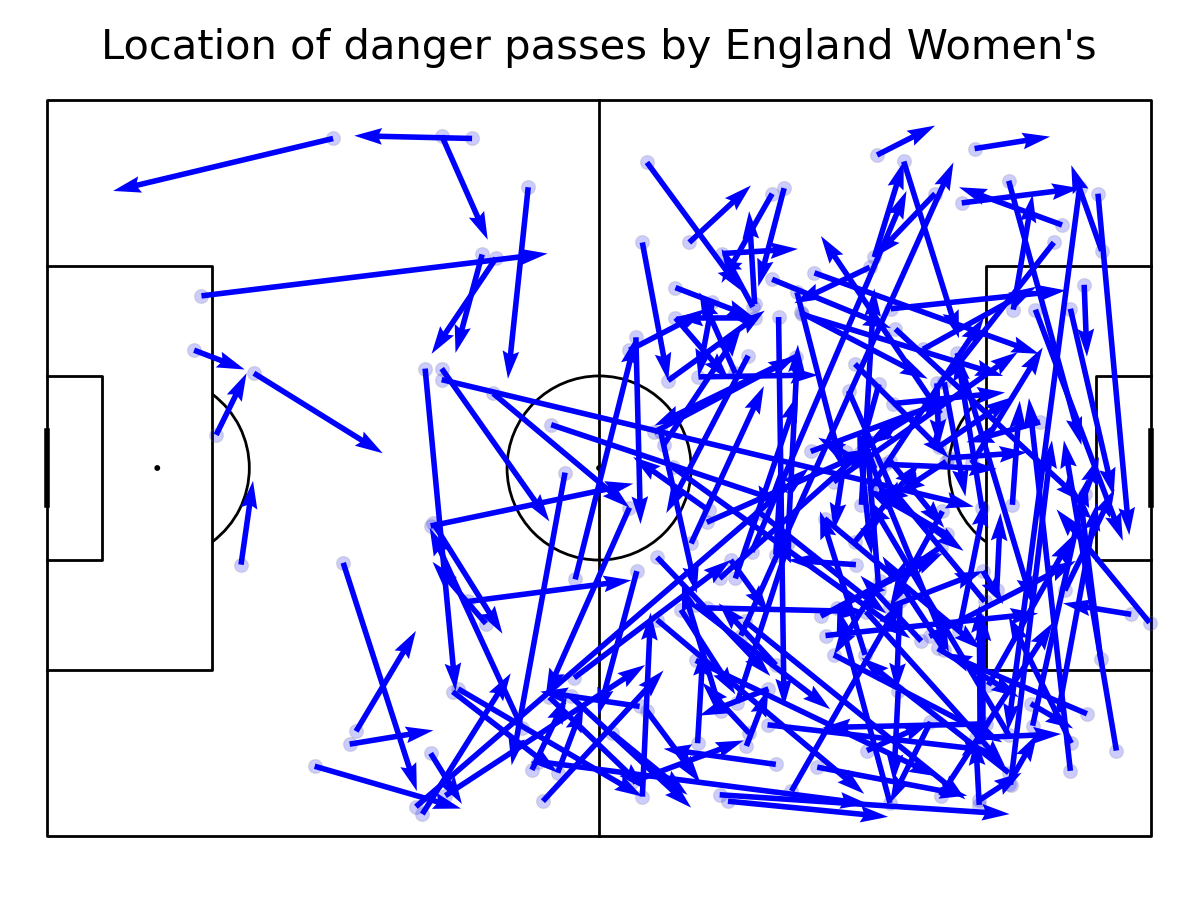

In [5]:
#plot pitch
pitch = Pitch(line_color='black')
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
#scatter the location on the pitch
pitch.scatter(danger_passes.x, danger_passes.y, s=100, color='blue', edgecolors='grey', linewidth=1, alpha=0.2, ax=ax["pitch"])
#uncomment it to plot arrows
pitch.arrows(danger_passes.x, danger_passes.y, danger_passes.end_x, danger_passes.end_y, color = "blue", ax=ax['pitch'])
#add title
fig.suptitle('Location of danger passes by ' + team, fontsize = 30)
plt.show()

## Making a heat map
To make a heat map, first, we draw a pitch. Then we calculate the number of passes in each bin using *bin_statistic* method.
Then, we normalize number of passes by number of games. We plot a heat map and then, we make a legend. As the last step, we add 
the title. 



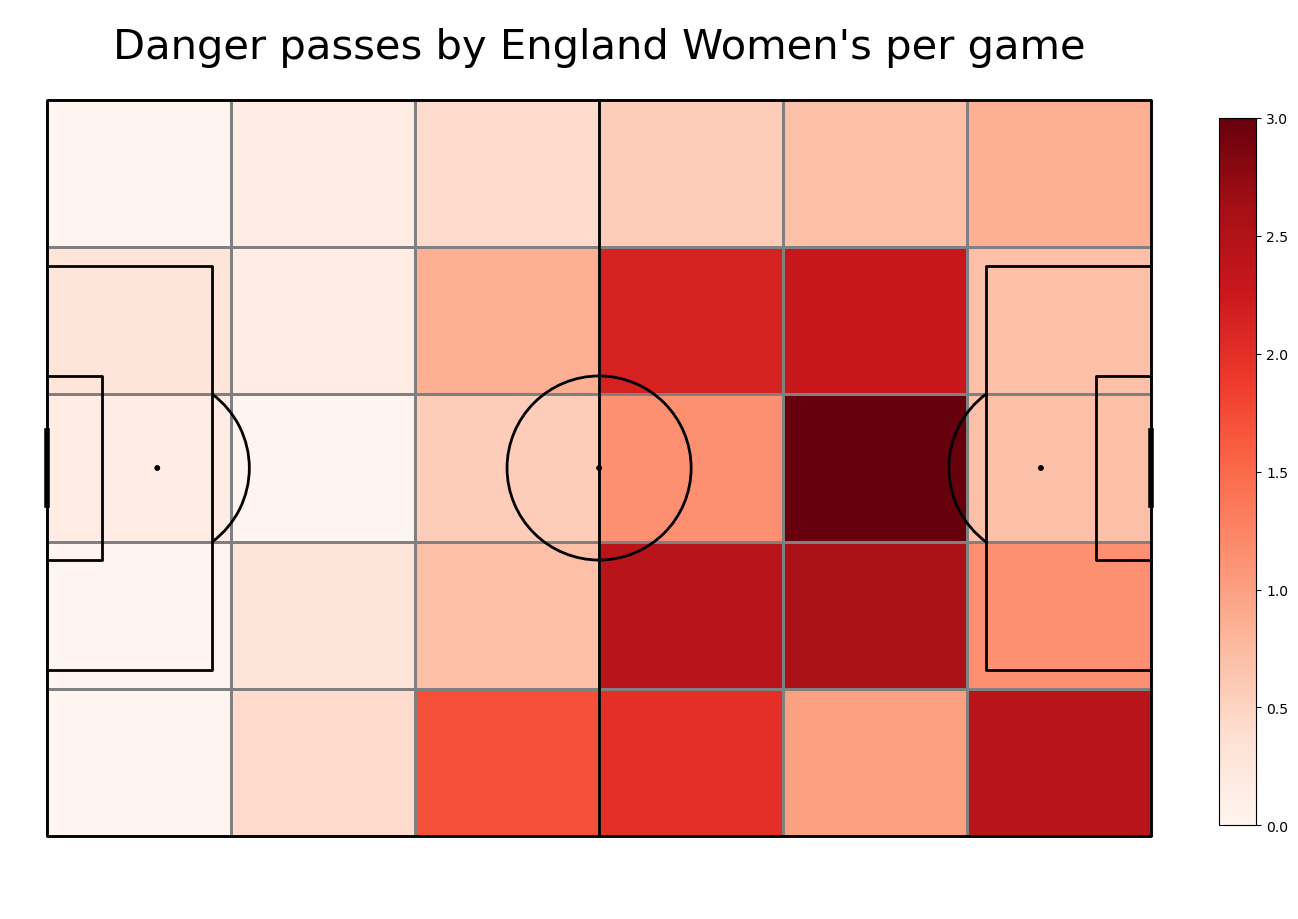

In [6]:
#plot vertical pitch
pitch = Pitch(line_zorder=2, line_color='black')
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
#get the 2D histogram 
bin_statistic = pitch.bin_statistic(danger_passes.x, danger_passes.y, statistic='count', bins=(6, 5), normalize=False)
#normalize by number of games
bin_statistic["statistic"] = bin_statistic["statistic"]/no_games
#make a heatmap
pcm  = pitch.heatmap(bin_statistic, cmap='Reds', edgecolor='grey', ax=ax['pitch'])
#legend to our plot
ax_cbar = fig.add_axes((1, 0.093, 0.03, 0.786))
cbar = plt.colorbar(pcm, cax=ax_cbar)
fig.suptitle('Danger passes by ' + team + " per game", fontsize = 30)
plt.show()

## Making a diagram of most involved players
To find out who was the most involved in dnager passes, we keep only surnames of players to make the vizualisation clearer.
Then, we group the passes by the player and count them. Also, we divide them by number of games to keep the diagram per game.
As the last step, we make the legend to our diagram.



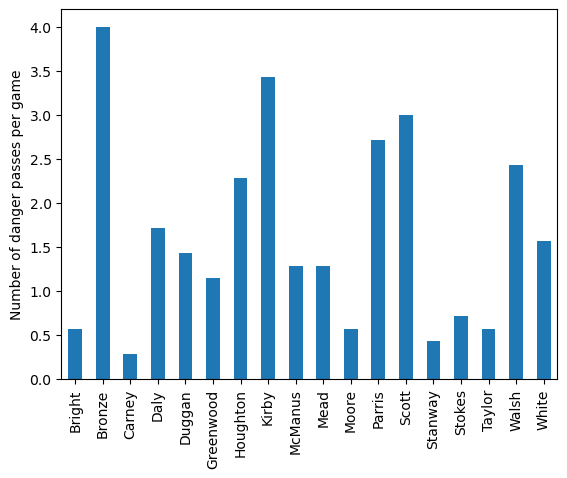

In [7]:
#keep only surnames
danger_passes["player_name"] = danger_passes["player_name"].apply(lambda x: str(x).split()[-1])
#count passes by player and normalize them
pass_count = danger_passes.groupby(["player_name"]).x.count()/no_games
#make a histogram
ax = pass_count.plot.bar(pass_count)
#make legend
ax.set_xlabel("")
ax.set_ylabel("Number of danger passes per game")
plt.show()

## Challenge
1) Improve so that only high xG (>0.07) are included!
2) Make a heat map only for Sweden's player who was the most involved in danger passes!



### 1) Only High xG (>0.07)

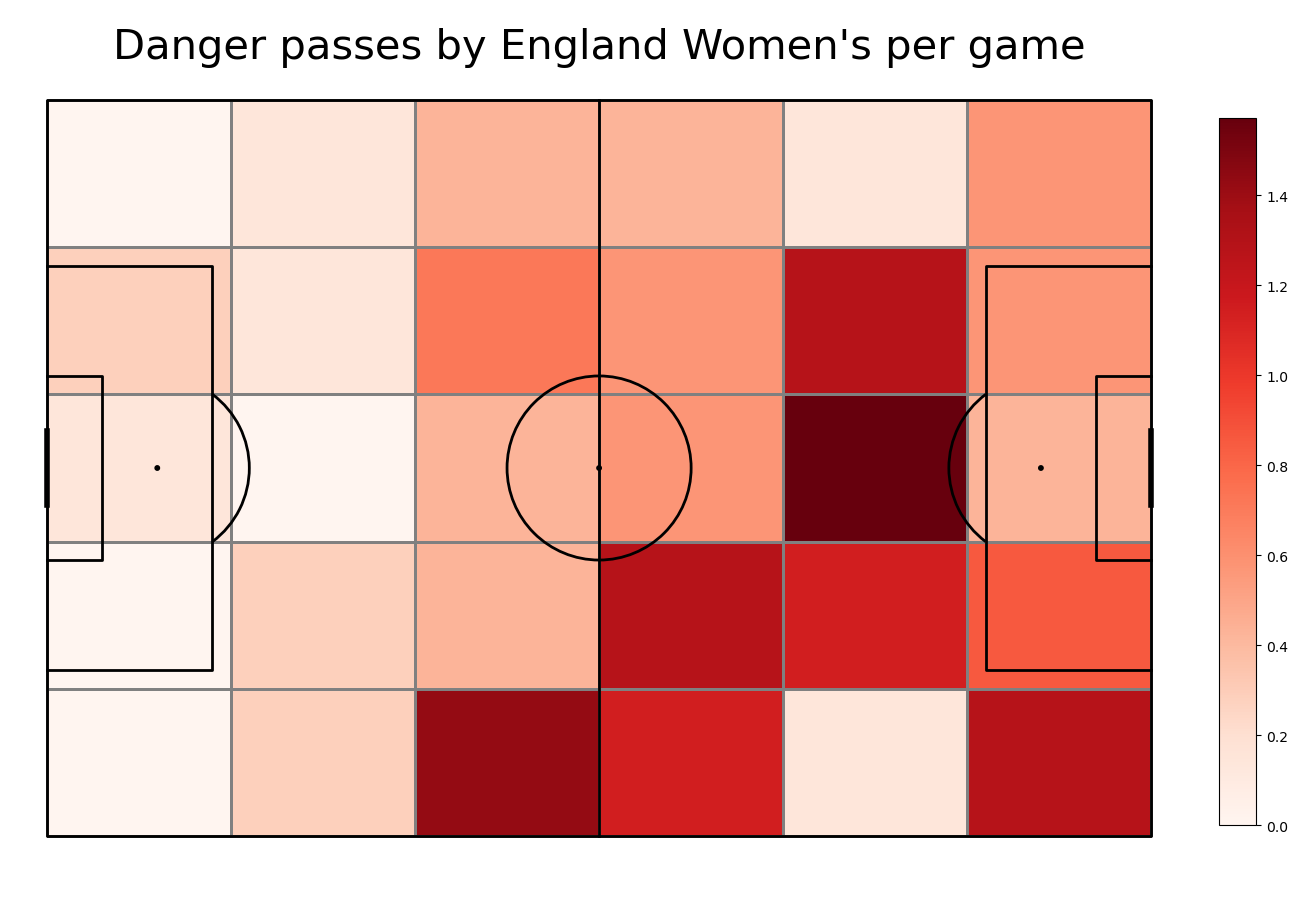

In [10]:
# mask for xG > 0.07
df_danger_shots = df_all_events[df_all_events['type_name'] == 'Shot']
df_danger_shots = df_danger_shots[df_danger_shots['shot_statsbomb_xg'] > 0.07]
#Only keep the necessary columns about shots
df_danger_shots = df_danger_shots[['match_id', 'possession', 'time_seconds']]
#Take out the open play successful passes from the possession team
df_passes = df_all_events[(df_all_events['type_name'] == 'Pass') 
                          & (df_all_events['outcome_name'].isnull()) 
                          & (df_all_events['possession_team_id'] == df_all_events['team_id'])
                          & (~df_all_events.sub_type_name.isin(['Throw-in','Corner','Free Kick', 'Kick Off', 'Goal Kick']))
                          ]
# Merge shots and passes on possession and match_id
# Use a inner join to keep only passes that have a matching shot in the same possession  
df_merged = df_danger_shots.merge(df_passes, on=['possession', 'match_id'], how='inner',suffixes=('_shot',''))
# Calculate time difference between pass and shot
df_merged['time_diff'] = df_merged['time_seconds_shot'] - df_merged['time_seconds']
# Keep only passes that occurred within 15 seconds before the shot
df_danger_passes = df_merged[df_merged['time_diff'].between(0,15)]
# Some possessions may have multiple shots, keep only the shot with the smallest time_diff to each pass
first_shot = df_danger_passes.groupby('id')['time_diff'].idxmin()
df_danger_passes = df_danger_passes.loc[first_shot].reset_index(drop=True)
# Filter for our team
df_danger_passes = df_danger_passes[df_danger_passes['team_name'] == team]
# Only keep necessary columns
danger_passes = df_danger_passes[['x', 'y', 'end_x', 'end_y', 'minute','second','player_name']]


#plot vertical pitch
pitch = Pitch(line_zorder=2, line_color='black')
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
#get the 2D histogram 
bin_statistic = pitch.bin_statistic(danger_passes.x, danger_passes.y, statistic='count', bins=(6, 5), normalize=False)
#normalize by number of games
bin_statistic["statistic"] = bin_statistic["statistic"]/no_games
#make a heatmap
pcm  = pitch.heatmap(bin_statistic, cmap='Reds', edgecolor='grey', ax=ax['pitch'])
#legend to our plot
ax_cbar = fig.add_axes((1, 0.093, 0.03, 0.786))
cbar = plt.colorbar(pcm, cax=ax_cbar)
fig.suptitle('Danger passes by ' + team + " per game", fontsize = 30)
plt.show()

### 2) Make a heatmap only for Sweden's most involved player

In [14]:
#open the data
parser = Sbopen()
df_match = parser.match(competition_id=72, season_id=30)
#our team
team = "Sweden Women's"
#get list of games by our team, either home or away
match_ids = df_match.loc[(df_match["home_team_name"] == team) | (df_match["away_team_name"] == team)]["match_id"].tolist()
#calculate number of games
no_games = len(match_ids)
print(no_games)

7


In [15]:
#Open event data for all matches and concatenate them
df_all_events = pd.DataFrame()
for match_id in match_ids:
    df_events = parser.event(match_id)[0]
    df_all_events = pd.concat([df_all_events, df_events])


#Identify danger passes
#Add time in seconds column
df_all_events["time_seconds"] = df_all_events["minute"]*60 + df_all_events["second"]
#Take out the shots
df_shots = df_all_events[(df_all_events['type_name'] == 'Shot')]
#Only keep the necessary columns about shots
df_shots = df_shots[['match_id', 'possession', 'time_seconds']]
#Take out the open play successful passes from the possession team
df_passes = df_all_events[(df_all_events['type_name'] == 'Pass') 
                          & (df_all_events['outcome_name'].isnull()) 
                          & (df_all_events['possession_team_id'] == df_all_events['team_id'])
                          & (~df_all_events.sub_type_name.isin(['Throw-in','Corner','Free Kick', 'Kick Off', 'Goal Kick']))
                          ]
# Merge shots and passes on possession and match_id
# Use a inner join to keep only passes that have a matching shot in the same possession  
df_merged = df_shots.merge(df_passes, on=['possession', 'match_id'], how='inner',suffixes=('_shot',''))
# Calculate time difference between pass and shot
df_merged['time_diff'] = df_merged['time_seconds_shot'] - df_merged['time_seconds']
# Keep only passes that occurred within 15 seconds before the shot
df_danger_passes = df_merged[df_merged['time_diff'].between(0,15)]
# Some possessions may have multiple shots, keep only the shot with the smallest time_diff to each pass
first_shot = df_danger_passes.groupby('id')['time_diff'].idxmin()
df_danger_passes = df_danger_passes.loc[first_shot].reset_index(drop=True)
# Filter for our team
df_danger_passes = df_danger_passes[df_danger_passes['team_name'] == team]
# Only keep necessary columns
danger_passes = df_danger_passes[['x', 'y', 'end_x', 'end_y', 'minute','second','player_name']]

In [19]:
# find Sweden's player with most danger passes
danger_passes["player_name"] = danger_passes["player_name"].apply(lambda x: str(x).split()[-1])
pass_count = danger_passes.groupby(["player_name"]).x.count()/no_games

player_with_most_danger_passes = pass_count.idxmax()
print(player_with_most_danger_passes, "has the most danger passes per game with", pass_count.max())


Seger has the most danger passes per game with 3.4285714285714284


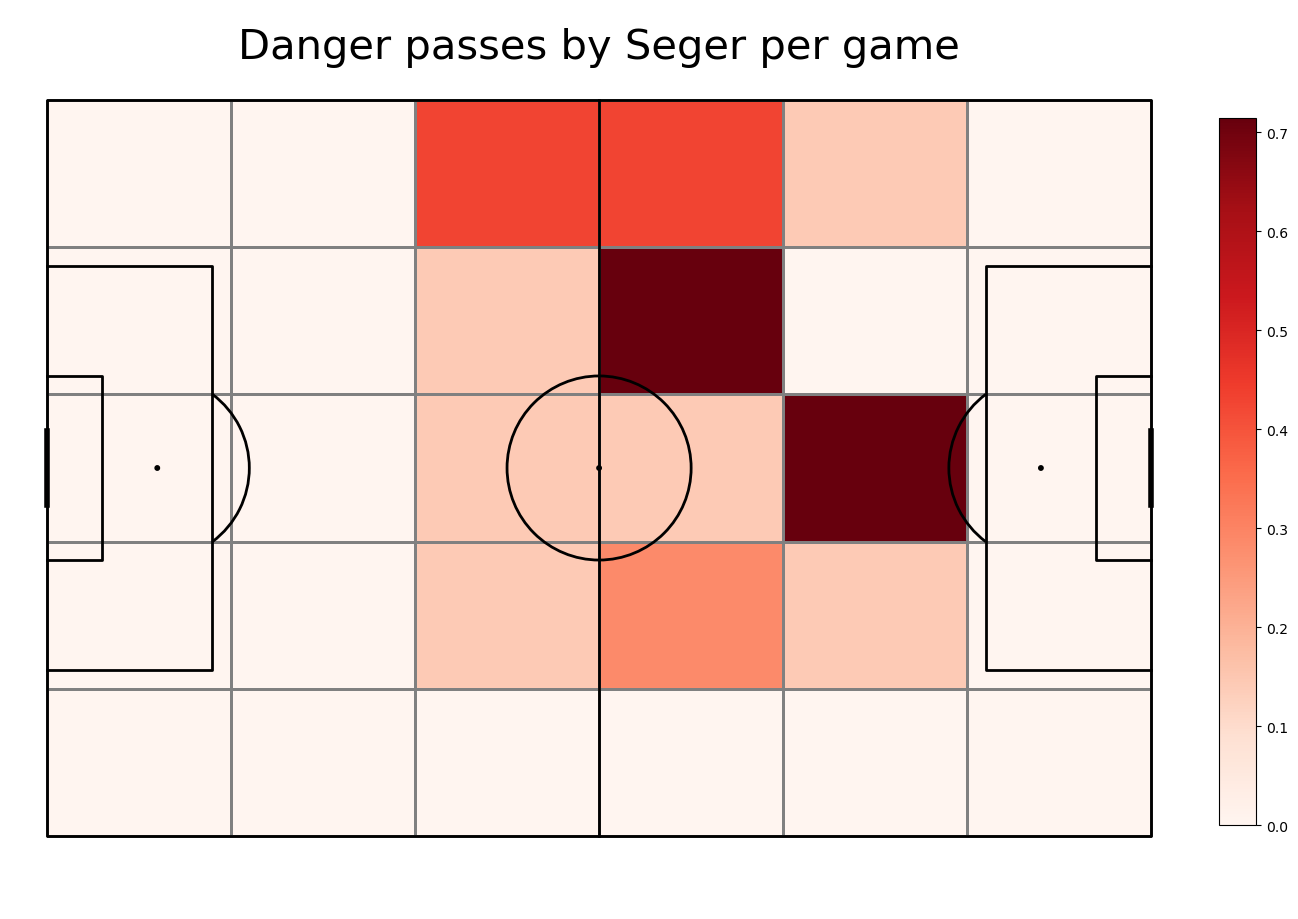

In [18]:
# Plot heatmap of player with most danger passes
pitch = Pitch(line_zorder=2, line_color='black')
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
seger_danger_passes = danger_passes[danger_passes['player_name'] == player_with_most_danger_passes]
#get the 2D histogram
bin_statistic = pitch.bin_statistic(seger_danger_passes.x, seger_danger_passes.y, statistic='count', bins=(6, 5), normalize=False)
#normalize by number of games
bin_statistic["statistic"] = bin_statistic["statistic"]/no_games
#make a heatmap
pcm  = pitch.heatmap(bin_statistic, cmap='Reds', edgecolor='grey', ax=ax['pitch'])
#legend to our plot
ax_cbar = fig.add_axes((1, 0.093, 0.03, 0.786))
cbar = plt.colorbar(pcm, cax=ax_cbar)
fig.suptitle('Danger passes by ' + player_with_most_danger_passes + " per game", fontsize = 30)
plt.show()